# Chapter 261 — Bayesian Inference in Practice
### Part VIII: Probability — Advanced Experiments

Bayes' theorem *(ch246)* tells us how to update beliefs. This chapter closes the loop: we apply it computationally, with conjugate priors for exact updates, and grid approximation for non-conjugate cases. The goal is to see Bayesian inference not as a formula but as a cycle: prior → likelihood → posterior → next prior.

**Prerequisites:** Bayes Theorem (ch246), Probability Distributions (ch248), Beta Distribution *(introduced here)*, Normal Distribution (ch253), Monte Carlo Methods (ch256).

## 1. Conjugate Priors: Beta-Binomial

The **Beta distribution** $\text{Beta}(\alpha, \beta)$ is conjugate to the Binomial likelihood. If:
- Prior: $\theta \sim \text{Beta}(\alpha, \beta)$
- Likelihood: $k \mid \theta \sim \text{Binomial}(n, \theta)$ (observe $k$ successes in $n$ trials)
- Posterior: $\theta \mid k \sim \text{Beta}(\alpha + k,\ \beta + n - k)$

The posterior is the same family — update is exact and closed-form.

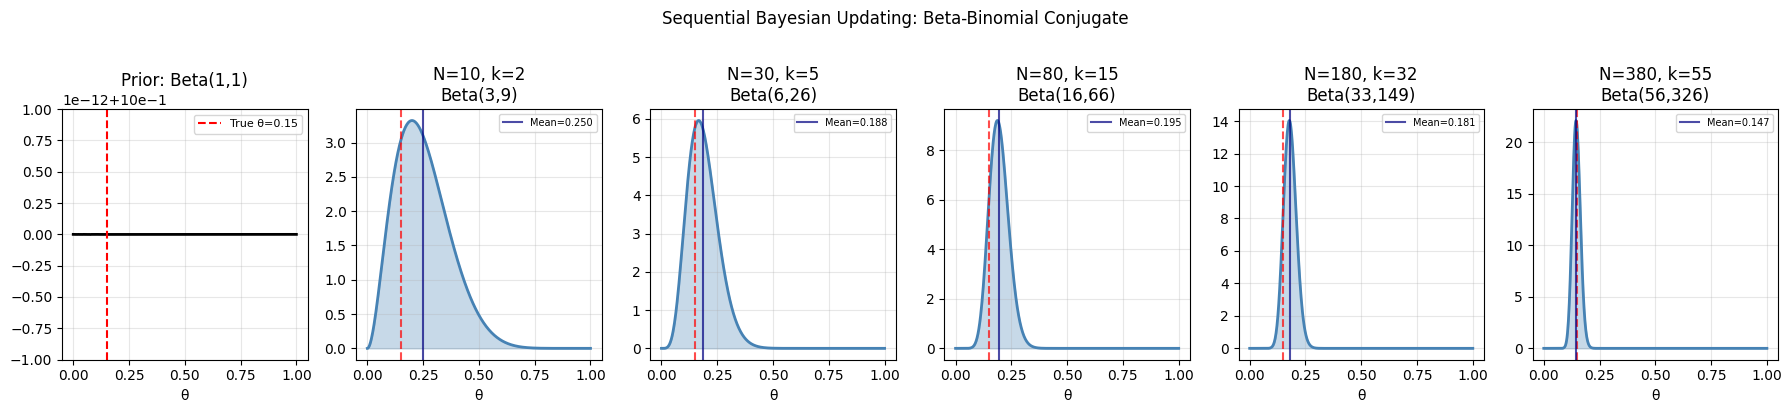

Final posterior: Beta(56, 326)
Posterior mean: 0.1466  (true: 0.15)
95% credible interval: [0.1130, 0.1837]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

def bayesian_update_beta(alpha, beta, n_successes, n_trials):
    """Update Beta prior given Binomial observations.
    
    Args:
        alpha, beta: prior Beta parameters
        n_successes: number of successes observed
        n_trials: total trials
    
    Returns:
        alpha_post, beta_post: posterior Beta parameters
    """
    alpha_post = alpha + n_successes
    beta_post = beta + (n_trials - n_successes)
    return alpha_post, beta_post

# Scenario: estimating conversion rate of a landing page
# True rate: 0.15. We observe batches of visitors sequentially.
true_rate = 0.15
alpha0, beta0 = 1.0, 1.0  # Uniform prior: Beta(1,1)

# Sequential batches of data
batch_sizes = [10, 20, 50, 100, 200]
cumulative_n = 0
cumulative_k = 0

theta_grid = np.linspace(0, 1, 500)
fig, axes = plt.subplots(1, len(batch_sizes) + 1, figsize=(18, 4))

# Prior
a, b = alpha0, beta0
axes[0].plot(theta_grid, stats.beta.pdf(theta_grid, a, b), 'k-', linewidth=2)
axes[0].axvline(true_rate, color='red', linestyle='--', label=f'True θ={true_rate}')
axes[0].set_title(f'Prior: Beta({a:.0f},{b:.0f})')
axes[0].set_xlabel('θ')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for ax, batch_n in zip(axes[1:], batch_sizes):
    # Simulate batch
    k = rng.binomial(batch_n, true_rate)
    cumulative_n += batch_n
    cumulative_k += k
    
    a, b = bayesian_update_beta(alpha0, beta0, cumulative_k, cumulative_n)
    
    posterior_pdf = stats.beta.pdf(theta_grid, a, b)
    ax.plot(theta_grid, posterior_pdf, 'steelblue', linewidth=2)
    ax.fill_between(theta_grid, posterior_pdf, alpha=0.3, color='steelblue')
    ax.axvline(true_rate, color='red', linestyle='--', alpha=0.7)
    ax.axvline(a/(a+b), color='navy', linestyle='-', alpha=0.7, label=f'Mean={a/(a+b):.3f}')
    ax.set_title(f'N={cumulative_n}, k={cumulative_k}\nBeta({a:.0f},{b:.0f})')
    ax.set_xlabel('θ')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sequential Bayesian Updating: Beta-Binomial Conjugate', y=1.02)
plt.tight_layout()
plt.savefig('bayesian_beta_binomial.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Final posterior: Beta({a:.0f}, {b:.0f})")
print(f"Posterior mean: {a/(a+b):.4f}  (true: {true_rate})")
# 95% credible interval
ci_lo, ci_hi = stats.beta.ppf([0.025, 0.975], a, b)
print(f"95% credible interval: [{ci_lo:.4f}, {ci_hi:.4f}]")

## 2. Grid Approximation for Non-Conjugate Posteriors

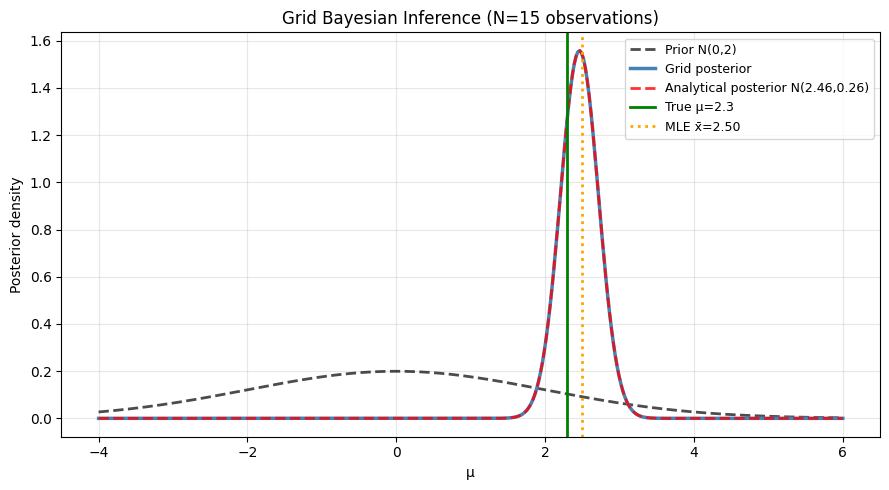

Grid posterior mean:       2.4610
Analytical posterior mean: 2.4610
True mean:                 2.3


In [4]:
def grid_posterior(prior_fn, likelihood_fn, theta_grid, observations):
    """Approximate posterior via grid discretization.
    
    posterior(θ) ∝ prior(θ) × likelihood(data|θ)
    Normalized over theta_grid.
    
    Args:
        prior_fn: callable(theta_grid) -> unnormalized prior density
        likelihood_fn: callable(theta, obs) -> log-likelihood scalar
        theta_grid: array of θ values
        observations: data array passed to likelihood_fn
    
    Returns:
        posterior: normalized posterior probabilities over theta_grid
    """
    log_prior = np.log(prior_fn(theta_grid) + 1e-300)
    log_lik = np.array([likelihood_fn(th, observations) for th in theta_grid])
    log_posterior = log_prior + log_lik
    # Normalize in log space for numerical stability
    log_posterior -= log_posterior.max()
    posterior = np.exp(log_posterior)
    posterior /= np.trapezoid(posterior, theta_grid)  # normalize (trapezoidal)
    return posterior

# Estimate the mean of a Normal with unknown mean, known variance
# Prior: Normal(0, sigma_prior=2)
# Likelihood: data ~ N(mu, sigma=1)
# Posterior should be: N(mu_post, sigma_post^2) — conjugate

true_mu = 2.3
sigma_lik = 1.0
sigma_prior = 2.0
n_obs = 15
data = rng.normal(true_mu, sigma_lik, n_obs)

# Grid
mu_grid = np.linspace(-4, 6, 400)

# Prior density
prior_fn = lambda th: stats.norm.pdf(th, 0, sigma_prior)

# Log-likelihood: sum of log N(mu, sigma) evaluated at data
log_lik_fn = lambda mu, obs: np.sum(stats.norm.logpdf(obs, mu, sigma_lik))

# Grid posterior
posterior = grid_posterior(prior_fn, log_lik_fn, mu_grid, data)

# Analytical conjugate posterior
sigma_post = 1 / np.sqrt(n_obs/sigma_lik**2 + 1/sigma_prior**2)
mu_post = sigma_post**2 * (data.mean() * n_obs/sigma_lik**2 + 0/sigma_prior**2)
analytical_posterior = stats.norm.pdf(mu_grid, mu_post, sigma_post)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mu_grid, prior_fn(mu_grid), 'k--', linewidth=2, alpha=0.7, label='Prior N(0,2)')
ax.plot(mu_grid, posterior, 'steelblue', linewidth=2.5, label='Grid posterior')
ax.plot(mu_grid, analytical_posterior, 'r--', linewidth=2,
        alpha=0.8, label=f'Analytical posterior N({mu_post:.2f},{sigma_post:.2f})')
ax.axvline(true_mu, color='green', linestyle='-', linewidth=2, label=f'True μ={true_mu}')
ax.axvline(data.mean(), color='orange', linestyle=':', linewidth=2, label=f'MLE x̄={data.mean():.2f}')
ax.set_xlabel('μ')
ax.set_ylabel('Posterior density')
ax.set_title(f'Grid Bayesian Inference (N={n_obs} observations)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bayesian_grid.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Grid posterior mean:       {np.trapezoid(mu_grid * posterior, mu_grid):.4f}")
print(f"Analytical posterior mean: {mu_post:.4f}")
print(f"True mean:                 {true_mu}")

## 9. Forward References

- **ch283 — Bayesian Statistics** *(Part IX)*: Extends to MCMC sampling for posteriors that are intractable even on a grid — the standard tool for modern Bayesian analysis.
- **ch284 — Information Theory** *(Part IX)*: KL divergence measures the distance between posterior and prior — quantifying how much the data shifts the belief.